In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split


# CHARGEMENT ET PRÉPARATION DES DONNÉES

In [ ]:

# Chargement du dataset généré à l'étape 0
df = pd.read_csv('csv/dataset.csv') # pour notebook dans vscode
df = pd.read_csv('dataset.csv') # pour notebook dans collab


# Les 18 features d'entrée
feature_cols = [f'c{i}_x' for i in range(9)] + [f'c{i}_o' for i in range(9)]

X = df[feature_cols]
y_xwins = df['x_wins']
y_draw   = df['is_draw']

# Distribution des classes (pour info)
print("=== Distribution des classes ===")
print("x_wins :", y_xwins.value_counts(normalize=True))
print("is_draw:", y_draw.value_counts(normalize=True))
print("\n")


=== Distribution des classes ===
x_wins : x_wins
1    0.668127
0    0.331873
Name: proportion, dtype: float64
is_draw: is_draw
0    0.838992
1    0.161008
Name: proportion, dtype: float64




### Analyse des distributions


Analyse de x_wins:


,Nombre,Pourcentage (%)
x_wins,,
1,1830,66.812705
0,909,33.187295


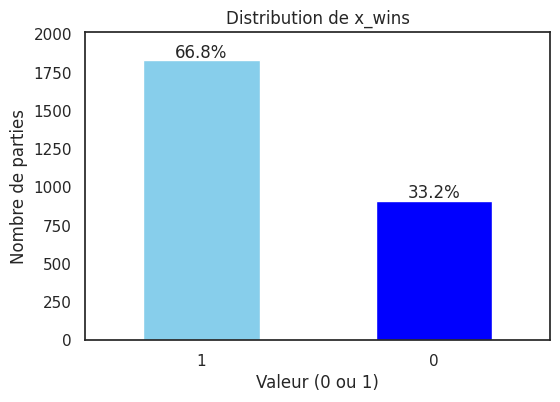


Interpretation :
Le dataset est DÉSÉQUILIBRÉ
Métrique privilégiée : F1-Score

Analyse de is_draw:


,Nombre,Pourcentage (%)
is_draw,,
0,2298,83.899233
1,441,16.100767


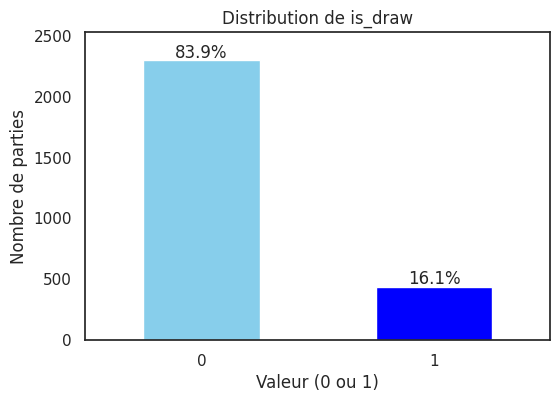


Interpretation :
Le dataset est DÉSÉQUILIBRÉ
Métrique privilégiée : F1-Score


In [ ]:
distributions = ['x_wins', 'is_draw']

for col in distributions:
    print(f"\nAnalyse de {col}:")
    counts = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100

    stats = pd.DataFrame({'Nombre': counts, 'Pourcentage (%)': percent})
    display(stats)

    plt.figure(figsize=(6, 4))
    ax = counts.plot(kind='bar', color=['skyblue', 'blue'])
    for i, p in enumerate(percent):
        ax.text(i, counts.iloc[i] + (counts.max() * 0.01), f'{p:.1f}%',
                ha='center')
    plt.title(f'Distribution de {col}')
    plt.xlabel('Valeur (0 ou 1)')
    plt.ylabel('Nombre de parties')
    plt.xticks(rotation=0)
    plt.ylim(0, counts.max() * 1.1)
    plt.show()

    ratio = counts.min() / counts.max()

    print(f"\nInterpretation :")
    if ratio < 0.5:
        print(f"Le dataset est DÉSÉQUILIBRÉ")
        print("Métrique privilégiée : F1-Score")
    else:
        print(f"Le dataset est relativement ÉQUILIBRÉ")
        print("Métrique privilégiée : Accuracy.")

#### Case la plus occpée par X

In [ ]:
victories_x = df[df['x_wins'] == 1]
cols_x = [f'c{i}_x' for i in range(9)]
occurences_par_case = victories_x[cols_x].sum()
display(occurences_par_case)
case_max = occurences_par_case.idxmax()
valeur_max = occurences_par_case.max()
print(f"La case la plus occupée par X lorsqu'il gagne est : {case_max} ({valeur_max} fois)")

,0
c0_x,569
c1_x,521
c2_x,569
c3_x,521
c4_x,592
c5_x,521
c6_x,569
c7_x,521
c8_x,569


La case la plus occupée par X lorsqu'il gagne est : c4_x (592 fois)


### Heatmap

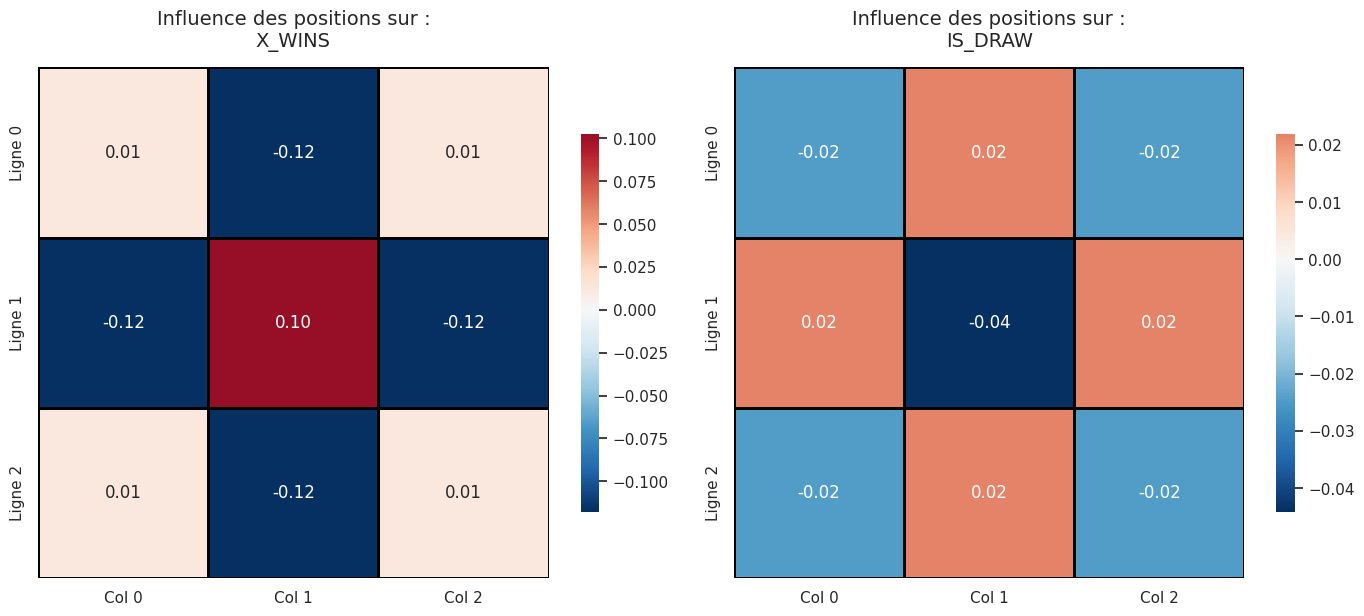

In [ ]:
distributions = ['x_wins', 'is_draw']

features_x = [f'c{i}_x' for i in range(9)]

plt.figure(figsize=(14, 6))


for i, cible in enumerate(distributions):

    corr_vector = df[features_x].corrwith(df[cible])

    corr_matrix = corr_vector.values.reshape(3, 3)

    plt.subplot(1, 2, i+1)
    sns.heatmap(corr_matrix,
                annot=True,
                fmt=".2f",
                cmap="RdBu_r",
                center=0,
                square=True,
                linewidths=2,
                linecolor='black',
                cbar_kws={"shrink": .7},
                xticklabels=['Col 0', 'Col 1', 'Col 2'],
                yticklabels=['Ligne 0', 'Ligne 1', 'Ligne 2'])

    plt.title(f'Influence des positions sur :\n{cible.upper()}', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# ÉTAPE 2 — BASELINE : RÉGRESSION LOGISTIQUE

In [3]:

print("=== ÉTAPE 2 : Baseline avec Régression Logistique (2 modèles indépendants) ===")

# Fonction pour entraîner et évaluer un modèle
def train_and_evaluate(y, target_name):
    # Séparation train / test (stratifiée pour garder la même répartition des classes)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # Entraînement
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Prédictions sur le test
    y_pred = model.predict(X_test)

    print(f"\n--- Modèle {target_name} ---")
    print("Accuracy  :", round(accuracy_score(y_test, y_pred), 4))
    print("F1-score  :", round(f1_score(y_test, y_pred), 4))
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred, zero_division=0))

    return model


=== ÉTAPE 2 : Baseline avec Régression Logistique (2 modèles indépendants) ===


### Entraînement des deux modèles

In [4]:

# evaluation des 2 models, win - draw
lr_xwins = train_and_evaluate(y_xwins, "x_wins")
lr_draw  = train_and_evaluate(y_draw,  "is_draw")


--- Modèle x_wins ---
Accuracy  : 0.6788
F1-score  : 0.7782

Rapport de classification :
              precision    recall  f1-score   support

           0       0.52      0.35      0.42       227
           1       0.72      0.84      0.78       458

    accuracy                           0.68       685
   macro avg       0.62      0.60      0.60       685
weighted avg       0.66      0.68      0.66       685


--- Modèle is_draw ---
Accuracy  : 0.8394
F1-score  : 0.0

Rapport de classification :
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       575
           1       0.00      0.00      0.00       110

    accuracy                           0.84       685
   macro avg       0.42      0.50      0.46       685
weighted avg       0.70      0.84      0.77       685




### ANALYSE DES COEFFICIENTS


=== Cartes des coefficients des deux modèles ===


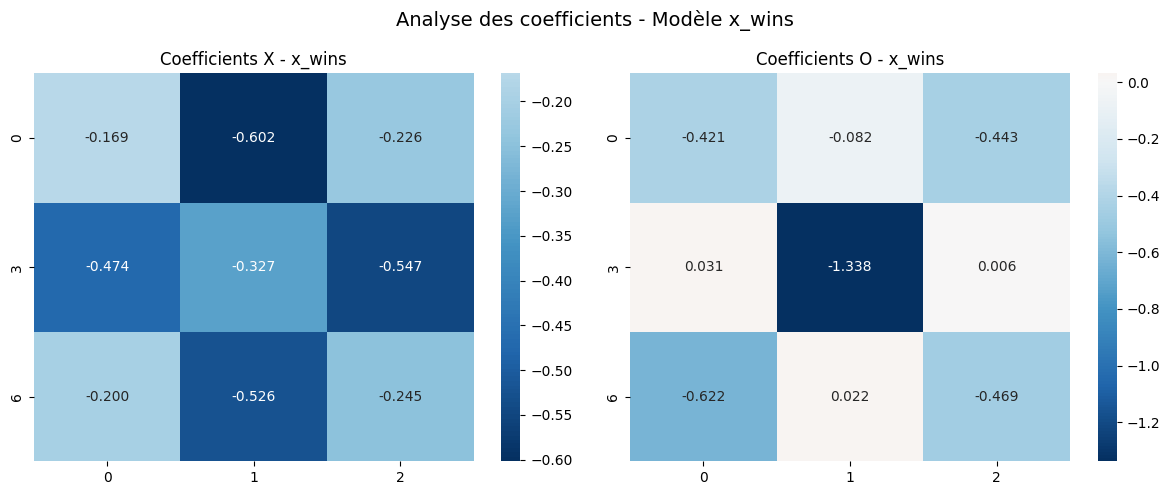

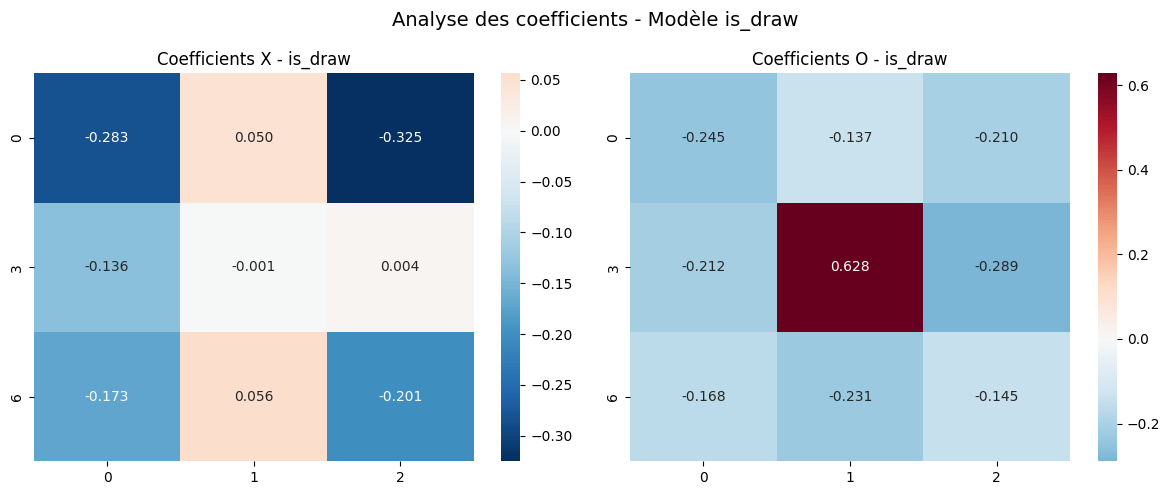


Top 8 features les plus influentes |coeff| - Modèle x_wins :
c4_o    1.337815
c6_o    0.622037
c1_x    0.601891
c5_x    0.546908
c7_x    0.525586
c3_x    0.474176
c8_o    0.469028
c2_o    0.443329
dtype: float64

Top 8 features les plus influentes |coeff| - Modèle is_draw :
c4_o    0.628263
c2_x    0.325164
c5_o    0.289294
c0_x    0.282846
c0_o    0.245000
c7_o    0.230942
c3_o    0.211843
c2_o    0.209872
dtype: float64


In [5]:


def plot_coefficients(model, target_name):
    """
    Affiche les coefficients des 18 features sous forme de deux cartes 3x3 :
    une pour X et une pour O.
    """
    coeffs = model.coef_[0]

    # Coefficients X (cases 0-8) et O (cases 0-8)
    coef_x = coeffs[:9].reshape(3, 3)
    coef_o = coeffs[9:].reshape(3, 3)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(coef_x, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax[0],
                xticklabels=['0','1','2'], yticklabels=['0','3','6'])
    ax[0].set_title(f'Coefficients X - {target_name}')

    sns.heatmap(coef_o, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax[1],
                xticklabels=['0','1','2'], yticklabels=['0','3','6'])
    ax[1].set_title(f'Coefficients O - {target_name}')

    plt.suptitle(f'Analyse des coefficients - Modèle {target_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n=== Cartes des coefficients des deux modèles ===")
plot_coefficients(lr_xwins, "x_wins")
plot_coefficients(lr_draw,  "is_draw")

# Top 8 features les plus influentes
print("\nTop 8 features les plus influentes |coeff| - Modèle x_wins :")
print(pd.Series(lr_xwins.coef_[0], index=feature_cols)
      .abs().sort_values(ascending=False).head(8))

print("\nTop 8 features les plus influentes |coeff| - Modèle is_draw :")
print(pd.Series(lr_draw.coef_[0], index=feature_cols)
      .abs().sort_values(ascending=False).head(8))

#  ÉTAPE 3 : MODÈLES AVANCÉS

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

In [10]:


print("\n=== ÉTAPE 3 : Modèles Avancés ===")
print("On compare 4 modèles plus puissants que la régression logistique.\n")

# Définition des modèles avec leurs hyperparamètres
models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200,
                                           max_depth=12,
                                           random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200,
                             max_depth=8,
                             learning_rate=0.1,
                             random_state=42,
                             eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32),
                         max_iter=1000,
                         random_state=42)
}

results = {}

for name, base_model in models.items():
    print(f"\n--- Modèle : {name} ---")

    # ------------------- Modèle pour x_wins -------------------
    # On crée une nouvelle instance pour chaque cible
    model_x = base_model.__class__(**base_model.get_params())
    model_x.fit(X, y_xwins)
    pred_x = model_x.predict(X)

    acc_x = accuracy_score(y_xwins, pred_x)
    f1_x  = f1_score(y_xwins, pred_x)

    results[f"{name}_xwins"] = {"Acc": acc_x, "F1": f1_x}

    print(f"x_wins  → Accuracy : {acc_x:.4f} | F1-score : {f1_x:.4f}")

    # ------------------- Modèle pour is_draw -------------------
    model_d = base_model.__class__(**base_model.get_params())
    model_d.fit(X, y_draw)
    pred_d = model_d.predict(X)

    acc_d = accuracy_score(y_draw, pred_d)
    f1_d  = f1_score(y_draw, pred_d)

    results[f"{name}_draw"] = {"Acc": acc_d, "F1": f1_d}

    print(f"is_draw → Accuracy : {acc_d:.4f} | F1-score : {f1_d:.4f}")

#  RÉSUMÉ DES PERFORMANCES
print("\n=== Résumé comparatif des modèles ===")
summary_df = pd.DataFrame(results).T.round(4)
print(summary_df)



=== ÉTAPE 3 : Modèles Avancés ===
On compare 4 modèles plus puissants que la régression logistique.


--- Modèle : DecisionTree ---
x_wins  → Accuracy : 0.8496 | F1-score : 0.8908
is_draw → Accuracy : 0.8938 | F1-score : 0.6216

--- Modèle : RandomForest ---
x_wins  → Accuracy : 0.9956 | F1-score : 0.9967
is_draw → Accuracy : 0.9883 | F1-score : 0.9624

--- Modèle : XGBoost ---
x_wins  → Accuracy : 1.0000 | F1-score : 1.0000
is_draw → Accuracy : 1.0000 | F1-score : 1.0000

--- Modèle : MLP ---
x_wins  → Accuracy : 1.0000 | F1-score : 1.0000
is_draw → Accuracy : 1.0000 | F1-score : 1.0000

=== Résumé comparatif des modèles ===
                       Acc      F1
DecisionTree_xwins  0.8496  0.8908
DecisionTree_draw   0.8938  0.6216
RandomForest_xwins  0.9956  0.9967
RandomForest_draw   0.9883  0.9624
XGBoost_xwins       1.0000  1.0000
XGBoost_draw        1.0000  1.0000
MLP_xwins           1.0000  1.0000
MLP_draw            1.0000  1.0000



=== Cartes des coefficients des deux modèles ===


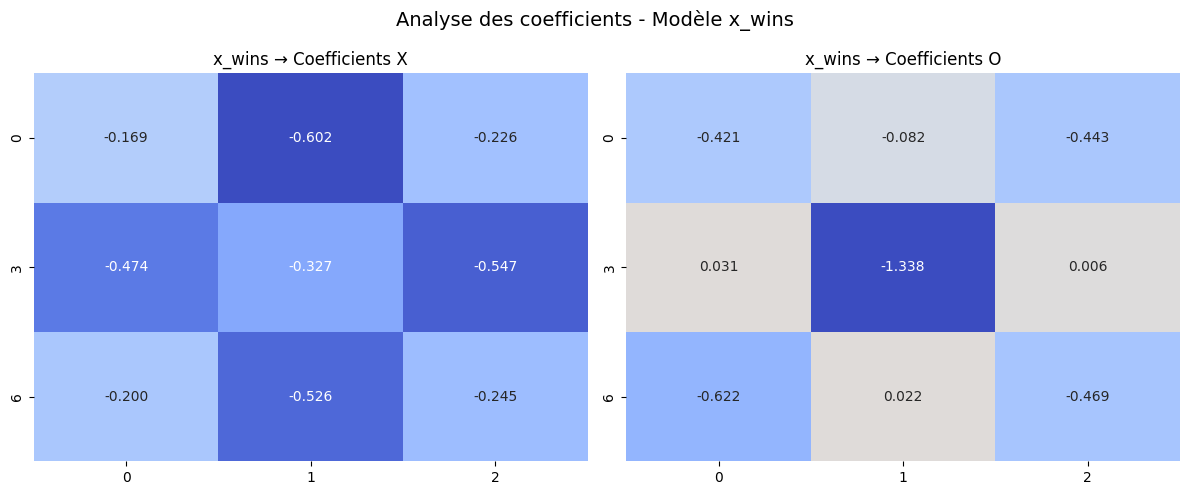

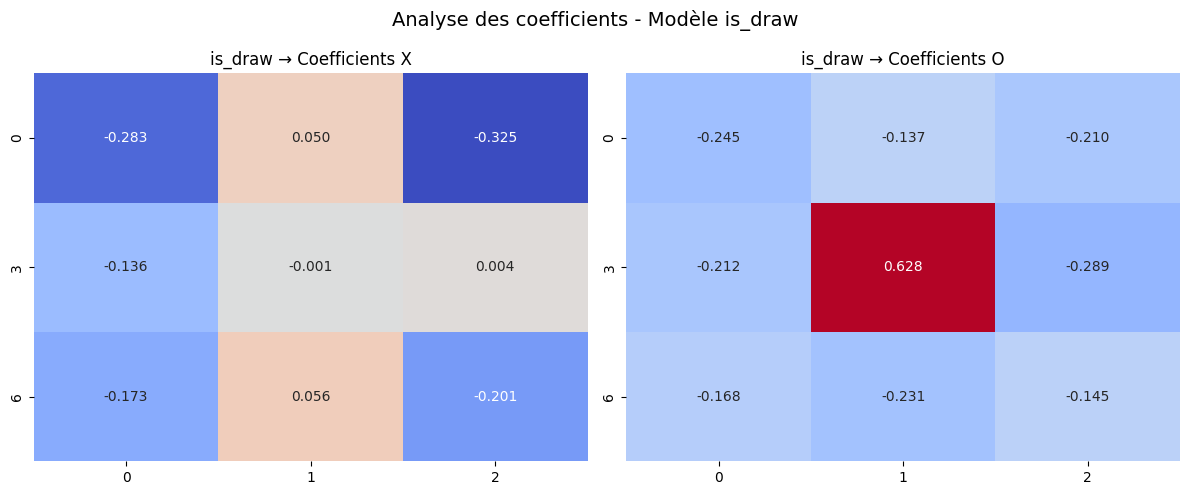

In [11]:

# import seaborn as sns
# import matplotlib.pyplot as plt

def plot_coefficients(model, target_name):
    """
    Affiche les coefficients du modèle sous forme de deux cartes 3x3 :
    - une carte pour les cases occupées par X
    - une carte pour les cases occupées par O
    """
    # Extraction des 18 coefficients
    coeffs = model.coef_[0]

    # Séparation : 9 premiers = X, 9 suivants = O
    coef_x = coeffs[0:9].reshape(3, 3)
    coef_o = coeffs[9:18].reshape(3, 3)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Carte des coefficients pour X
    sns.heatmap(coef_x, annot=True, fmt=".3f", cmap="coolwarm",
                center=0, ax=ax[0], cbar=False)
    ax[0].set_title(f"{target_name} → Coefficients X")
    ax[0].set_xticklabels(['0', '1', '2'])
    ax[0].set_yticklabels(['0', '3', '6'])

    # Carte des coefficients pour O
    sns.heatmap(coef_o, annot=True, fmt=".3f", cmap="coolwarm",
                center=0, ax=ax[1], cbar=False)
    ax[1].set_title(f"{target_name} → Coefficients O")
    ax[1].set_xticklabels(['0', '1', '2'])
    ax[1].set_yticklabels(['0', '3', '6'])

    plt.suptitle(f"Analyse des coefficients - Modèle {target_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


print("\n=== Cartes des coefficients des deux modèles ===")

# Affichage pour les deux baselines (modèles entraînés à l'étape 2)
plot_coefficients(lr_xwins, "x_wins")
plot_coefficients(lr_draw,  "is_draw")

###  GÉNÉRATION ET SAUVEGARDE DES MODÈLES FINAUX 

In [ ]:

print("\n=== Génération des modèles finaux pour l'interface ===")
print("On entraîne les meilleurs modèles (XGBoost) sur l'ensemble des données")
print("et on les sauvegarde pour pouvoir les charger dans l'interface jouable.\n")

model_win = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model_win.fit(X, y_xwins)
print("✓ Modèle x_wins entraîné")

model_draw = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model_draw.fit(X, y_draw)
print("✓ Modèle is_draw entraîné")



joblib.dump(model_win,  'models/xgb_xwins.joblib')
joblib.dump(model_draw, 'models/xgb_draw.joblib')

print("\n MODÈLES SAUVEGARDÉS AVEC SUCCÈS !")
print("   → xgb_xwins.joblib   (utilisé pour prédire si X gagne)")
print("   → xgb_draw.joblib  (utilisé pour prédire si match nul)")
print("\nCes deux fichiers sont maintenant prêts à être utilisés")